# Run Any Kind of OLS Regression (ANOVA, GLM, Logit, etc.)

### Authors: Calvin Howard.

#### Last updated: May 5, 2024

Use this to run/test a statistical model (e.g., regression or T-tests) on a spreadsheet containing covariates and brain image (nii/gii) paths. 

Notes:
- For this to work, it must be installed onto wherever you want to run it. You must run:
```
> git clone https://github.com/Calvinwhow/Research.git
> cd into wherever you installed it. 
> pip install -e .
```
- To best use this notebook, you should be familar with GLM design and Contrast Matrix design. See this webpage to get started:
[FSL's GLM page](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM)

# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

Prep Output Direction

In [1]:
# Specify where you want to save your results to
out_dir = '/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/results/attempted_localization/total-bars'

Import Data

In [2]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/master_list_redo.csv'
sheet = None

In [3]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()
data_df

,paths,onetouch_path,subid,session,selected,all_data_present,id,local_id,diagnosis,scan_type,...,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,Nifti_File_Path,cosine_Affect_Total,cosine_Total_CCAS_Fail,cosine_Total_BARS,cosine_Total_BARS_redo
0,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,3,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.024718,-0.012788,0.187846,-0.013404
1,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,4,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.019786,-0.012873,0.196872,-0.018949
2,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,5,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.041309,-0.117257,0.526450,-0.029840
3,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,6,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.019012,-0.011870,0.179335,-0.018037
4,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,272562,7,1,0,NaN,NaN,NaN,NaN,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.037358,-0.117441,0.526514,-0.030778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4760445,Cor_3D_SPGR,1,0,HA-01-016,HA-01-016-7301,SCA3,Cor_3D_SPGR,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.038287,-0.074549,0.119343,-0.016261
176,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5075289,Ax_Butler_BRAVO_Brain_Only,1,0,HA-01-035,HA-01-035-7301,SCA3,Ax_Butler_BRAVO_Brain_Only,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.074028,0.054746,0.263356,-0.129627
177,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,Mag_Images,0,1,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.019150,-0.081169,0.449252,-0.098578
178,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,AAHead_Scout,1,1,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.113756,-0.187981,0.200846,-0.148037



# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [4]:
data_df.columns

Index(['paths', 'onetouch_path', 'subid', 'session', 'selected',
       'all_data_present', 'id', 'local_id', 'diagnosis', 'scan_type',
       ...
       'CNRSTotColBScore', 'CNRSTotScore', 'roi_path', 'conn_path', 'dataset',
       'Nifti_File_Path', 'cosine_Affect_Total', 'cosine_Total_CCAS_Fail',
       'cosine_Total_BARS', 'cosine_Total_BARS_redo'],
      dtype='object', length=122)

In [5]:
drop_list = ['cosine_Total_BARS', 'TotalCCASFailScore', 'AffectFailS']

In [6]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
data_df

,paths,onetouch_path,subid,session,selected,all_data_present,id,local_id,diagnosis,scan_type,...,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,Nifti_File_Path,cosine_Affect_Total,cosine_Total_CCAS_Fail,cosine_Total_BARS,cosine_Total_BARS_redo
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,1,1,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.085743,0.029256,0.124496,0.007546
9,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,3,0,1,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.082220,0.027942,0.136655,-0.002936
10,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,4,0,1,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.083830,0.033810,0.123100,0.003830
29,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,1,0,1,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.096600,-0.076776,0.349383,-0.017745
30,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,2,0,1,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.075905,-0.063282,0.311245,-0.015534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4747492,SAG_BRAVO_REFMT,0,1,HA-01-009,HA-01-009-7301,SCA3,Ax_BRAVO_Brain_Only,...,-23.0,-54.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.345649,0.287301,0.134710,-0.174570
174,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4747492,COR_BRAVO_REFMT,0,1,HA-01-009,HA-01-009-7301,SCA3,Ax_BRAVO_Brain_Only,...,-23.0,-54.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.349018,0.280374,0.137274,-0.172020
177,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,Mag_Images,0,1,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.019150,-0.081169,0.449252,-0.098578
178,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,5623298,AAHead_Scout,1,1,HA-01-050,HA-01-050-7301,SCA3,Sag_T1_Pre,...,-5.0,-10.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.113756,-0.187981,0.200846,-0.148037


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [7]:
data_df.columns

Index(['paths', 'onetouch_path', 'subid', 'session', 'selected',
       'all_data_present', 'id', 'local_id', 'diagnosis', 'scan_type',
       ...
       'CNRSTotColBScore', 'CNRSTotScore', 'roi_path', 'conn_path', 'dataset',
       'Nifti_File_Path', 'cosine_Affect_Total', 'cosine_Total_CCAS_Fail',
       'cosine_Total_BARS', 'cosine_Total_BARS_redo'],
      dtype='object', length=122)

Set the parameters for dropping rows

In [8]:
column = 'selected'  # The column you'd like to evaluate
condition = 'not'  # The condition to check ('equal', 'above', 'below', 'not')
value = 1 # The value to drop if found

In [9]:
data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
display(data_df)

,paths,onetouch_path,subid,session,selected,all_data_present,id,local_id,diagnosis,scan_type,...,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,Nifti_File_Path,cosine_Affect_Total,cosine_Total_CCAS_Fail,cosine_Total_BARS,cosine_Total_BARS_redo
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,1,1,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.085743,0.029256,0.124496,0.007546
33,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,7,1,1,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.049009,0.058818,0.209854,-0.037461
36,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2368336,2,1,1,HA-01-002,HA-01-002-7301,SCA6,C__Cor_T1_3D,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.051208,0.094285,0.177708,-0.346097
38,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2369031,2,1,1,HA-01-091,HA-01-091-7301,SCA27B,MPR_Coronal_Ref___Revised_,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.133172,-0.222914,0.400881,0.051647
45,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,3241194,4,1,1,HA-01-089,HA-01-089-7301,SCA27B,27_Sag_T1_3D_MP_mitigation,...,-10.0,-17.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.055068,-0.153854,0.277111,0.007999
54,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4392765,4,1,1,HA-01-105,HA-01-105-7301,SCA27B,Sag_T1_3D_MPRAG_MPR_Ax_MPR,...,-1.0,-8.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.017278,-0.092910,0.200947,-0.112511
61,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4401431,6,1,1,HA-01-051,HA-01-051-7301,SCA6,Sag_T1_3D_MPRAG_mitigation,...,-16.0,-34.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.142563,0.205407,0.010975,-0.396866
63,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4530107,3,1,1,HA-01-010,HA-01-010-7301,SCA2,COR_MPR_PRE,...,-9.0,-12.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.023750,0.128689,0.032319,-0.178148
79,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4783569,6,1,1,HA-01-015,HA-01-015-7301,SCA3,Post_t1_SAG_MPRAGE,...,-16.0,-27.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.024025,0.105113,0.204624,-0.060000
84,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4792757,4,1,1,HA-01-031,HA-01-031-7301,SCA1,AXIAL_MPRAGE_RECONS,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.021696,0.038714,0.120570,-0.118631

Convert Categorical to Ordinal

One Hot Encode

In [10]:
import pandas as pd
# one_hot = pd.get_dummies(data_df['DX_BASELINE'], prefix='DX_BASELINE', dtype=int)
# data_df = data_df.join(one_hot)
data_df

,paths,onetouch_path,subid,session,selected,all_data_present,id,local_id,diagnosis,scan_type,...,CNRSTotColBScore,CNRSTotScore,roi_path,conn_path,dataset,Nifti_File_Path,cosine_Affect_Total,cosine_Total_CCAS_Fail,cosine_Total_BARS,cosine_Total_BARS_redo
8,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,1355923,2,1,1,HA-01-103,HA-01-103-7301,SCA27B,T1_MPRAGE_SAG,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.085743,0.029256,0.124496,0.007546
33,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2071224,7,1,1,HA-01-099,HA-01-099-7301,SCA27B,15_Sag_T1_3D_MP_PR_Cor_MPR,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.049009,0.058818,0.209854,-0.037461
36,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2368336,2,1,1,HA-01-002,HA-01-002-7301,SCA6,C__Cor_T1_3D,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.051208,0.094285,0.177708,-0.346097
38,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,2369031,2,1,1,HA-01-091,HA-01-091-7301,SCA27B,MPR_Coronal_Ref___Revised_,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.133172,-0.222914,0.400881,0.051647
45,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,3241194,4,1,1,HA-01-089,HA-01-089-7301,SCA27B,27_Sag_T1_3D_MP_mitigation,...,-10.0,-17.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.055068,-0.153854,0.277111,0.007999
54,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4392765,4,1,1,HA-01-105,HA-01-105-7301,SCA27B,Sag_T1_3D_MPRAG_MPR_Ax_MPR,...,-1.0,-8.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.017278,-0.092910,0.200947,-0.112511
61,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4401431,6,1,1,HA-01-051,HA-01-051-7301,SCA6,Sag_T1_3D_MPRAG_mitigation,...,-16.0,-34.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.142563,0.205407,0.010975,-0.396866
63,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4530107,3,1,1,HA-01-010,HA-01-010-7301,SCA2,COR_MPR_PRE,...,-9.0,-12.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.023750,0.128689,0.032319,-0.178148
79,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4783569,6,1,1,HA-01-015,HA-01-015-7301,SCA3,Post_t1_SAG_MPRAGE,...,-16.0,-27.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,-0.024025,0.105113,0.204624,-0.060000
84,/Volumes/HowExp/datasets/01p_Schmahmann_SCA_At...,/Volumes/OneTouch/01p_Schmahmann_SCA_Atrophy/S...,4792757,4,1,1,HA-01-031,HA-01-031-7301,SCA1,AXIAL_MPRAGE_RECONS,...,0.0,0.0,/Users/cu135/Partners HealthCare Dropbox/Calvi...,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,NAF,/Volumes/NIMLAB/dl_archive/Atrophy_Howard/01p_...,0.021696,0.038714,0.120570,-0.118631

# 02 - Define Your Formula

This is the formula relating outcome to predictors, and takes the form:
- y = B0 + B1 + B2 + B3 + . . . BN

It is defined using the columns of your dataframe instead of the variables above:
- 'Apples_Picked ~ hours_worked + owns_apple_picking_machine'

____
**ANOVA**
- Tests differences in means for one categorical variable.
- formula = 'Outcome ~ C(Group1)'

**2-Way ANOVA**
- Tests differences in means for two categorical variables without interaction.
- formula = 'Outcome ~ C(Group1) + C(Group2)'

**2-Way ANOVA with Interaction**
- Tests for interaction effects between two categorical variables.
- formula = 'Outcome ~ C(Group1) * C(Group2)'

**ANCOVA**
- Similar to ANOVA, but includes a covariate to control for its effect.
- formula = 'Outcome ~ C(Group1) + Covariate'

**2-Way ANCOVA**
- Extends ANCOVA with two categorical variables and their interaction, controlling for a covariate.
- formula = 'Outcome ~ C(Group1) * C(Group2) + Covariate'

**Multiple Regression**
- Assesses the impact of multiple predictors on an outcome.
- formula = 'Outcome ~ Predictor1 + Predictor2'

**Simple Linear Regression**
- Assesses the impact of a single predictor on an outcome.
- formula = 'Outcome ~ Predictor'

**MANOVA**
- Assesses multiple dependent variables across groups.
- Note: Not typically set up with a formula in statsmodels. Requires specialized functions.

____
Use the printout below to design your formula. 
- Left of the "~" symbol is the thing to be predicted. 
- Right of the "~" symbol are the predictors. 
- ":" indicates an interaction between two things. 
- "*" indicates and interactions AND it accounts for the simple effects too. 
- "+" indicates that you want to add another predictor. 

In [11]:
data_df.columns

Index(['paths', 'onetouch_path', 'subid', 'session', 'selected',
       'all_data_present', 'id', 'local_id', 'diagnosis', 'scan_type',
       ...
       'CNRSTotColBScore', 'CNRSTotScore', 'roi_path', 'conn_path', 'dataset',
       'Nifti_File_Path', 'cosine_Affect_Total', 'cosine_Total_CCAS_Fail',
       'cosine_Total_BARS', 'cosine_Total_BARS_redo'],
      dtype='object', length=122)

In [12]:
data_df['TotalBarsScore'] *= -1

/var/folders/82/946tskyj68b6htgvndtppmz80000gp/T/ipykernel_26970/4139484003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['TotalBarsScore'] *= -1


In [ ]:
formula = "TotalBarsScore ~ onetouch_path + AffectTotal + TotalCCASFailScore"

# 02 - Visualize Your Design Matrix

This is the explanatory variable half of your regression formula
_______________________________________________________
Create Design Matrix: Use the create_design_matrix method. You can provide a list of formula variables which correspond to column names in your dataframe.

- voxelwise_variable_list = A list containing the names of each variable that has voxelwise variables. Plainly, the variables that represent niftis. 
- By default, an intercept will be added unless you set intercept=False
- **don't explicitly add the 'intercept' column. I'll do it for you.**

In [42]:
voxelwise_variable_list=['onetouch_path']

If you want to run voxelwise INTERACTIONS, then you should specify the exact terms, exactly as specified in your above formula, here. 
- For example, if Formula is outcome ~ voxelwise_var1 * age + dog_number, then voxelwise_interaction_terms are ['voxelwise_var1 * age]
- Set voxelwise_interaction_terms = [] (left as an empty list) if you have no interactions with voxelwise variables

In [43]:
voxelwise_interaction_terms = []

Make sure ANY voxelwise variables are in formula. 

In [44]:
outcome_df, design_matrix = cal_palm.define_design_matrix(formula, data_df, add_intercept=True,
                                                          voxelwise_variable_list=voxelwise_variable_list, 
                                                          voxelwise_interaction_terms=voxelwise_interaction_terms)
design_matrix

Error because patsy is garbage: Error evaluating factor: NameError: name 'CCASFailS' is not defined
    TotalBarsScore ~ onetouch_path + AffectTotal + CCASFailS
                                                   ^^^^^^^^^. using fallback.


PatsyError: Error evaluating factor: NameError: name 'CCASFailS' is not defined
    TotalBarsScore ~ onetouch_path + AffectTotal + CCASFailS
                                                   ^^^^^^^^^

# 03 - Visualize Your Dependent Variable

I have generated this for you based on the formula you provided

In [32]:
outcome_df

,TotalBarsScore
8,5.0
33,6.5
36,21.5
38,3.0
45,6.5
54,6.0
61,24.5
63,6.5
79,9.5
84,5.0


# 04 - Generate Contrasts

Generate a Contrast Matrix
- This is different from the contrast matrices used in cell-means regressions such as in PALM, but it is much more powerful. 



For more information on contrast matrices, please refer to this: https://cran.r-project.org/web/packages/codingMatrices/vignettes/codingMatrices.pdf

Generally, these drastically effect the results of ANOVA. However, they are mereley a nuisance for a regression.
In essence, they assess if coefficients are significantly different

________________________________________________________________
A coding matrix (a contrast matrix if it sums to zero) is simply a way of defining what coefficients to evaluate and how to evaluate them. 
If a coefficient is set to 1 and everything else is set to zero, we are taking the mean of the coefficient's means and assessing if they significantly
deviate from zero--IE we are checking if it had a significant impact on the ability to predict the depdendent variable.
If a coefficient is set to 1, another is -1, and others are 0, we are assessing how the means of the two coefficients deviate from eachother. 
If several coefficients are 1 and several others are -1, we are assessing how the group-level means of the two coefficients deviate from eachother.
If a group of coefficients are 1, a group is -1, and a group is 0, we are only assessing how the groups +1 and -1 have differing means. 

1: This value indicates that the corresponding variable's coefficient in the model is included in the contrast. It means you are interested in estimating the effect of that variable.

0: This value indicates that the corresponding variable's coefficient in the model is not included in the contrast. It means you are not interested in estimating the effect of that variable.

-1: This value indicates that the corresponding variable's coefficient in the model is included in the contrast, but with an opposite sign. It means you are interested in estimating the negative effect of that variable.

----------------------------------------------------------------
The contrast matrix is typically a matrix with dimensions (number of contrasts) x (number of regression coefficients). Each row of the contrast matrix represents a contrast or comparison you want to test.

For example, let's say you have the following regression coefficients in your model:

Intercept, Age, connectivity, Age_interaction_connectivity
A contrast matric has dimensions of [n_predictors, n_experiments] where each experiment is a contrast

If you want to test the hypothesis that the effect of Age is significant, you can set up a contrast matrix with a row that specifies this contrast (actually an averaging vector):
```
[0,1,0,0]. This is an averaging vector because it sums to 1
```
This contrast will test the coefficient corresponding to the Age variable against zero.


If you want to test the hypothesis that the effect of Age is different from the effect of connectivity, you can set up a contrast matrix with two rows:
```
[0,1,−1,0]. This is a contrast because it sums to 0
```

Thus, if you want to see if any given effect is significant compared to the intercept (average), you can use the following contrast matrix:
```
[1,0,0,0]
[-1,1,0,0]
[-1,0,1,0]
[-1,0,0,1] actually a coding matrix of averaging vectors
```

The first row tests the coefficient for Age against zero, and the second row tests the coefficient for connectivity against zero. The difference between the two coefficients can then be assessed.
_____
You can define any number of contrasts in the contrast matrix to test different hypotheses or comparisons of interest in your regression analysis.

It's important to note that the specific contrasts you choose depend on your research questions and hypotheses. You should carefully consider the comparisons you want to make and design the contrast matrix accordingly.

- Examples:
    - [Two Sample T-Test](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM#Two-Group_Difference_.28Two-Sample_Unpaired_T-Test.29)
    - [One Sample with Covariate](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM#Single-Group_Average_with_Additional_Covariate)

In [33]:
contrast_matrix = cal_palm.generate_basic_contrast_matrix(design_matrix)

Here is a basic contrast matrix set up to evaluate the significance of each variable.
Here is an example of what your contrast matrix looks like as a dataframe: 
   Intercept  onetouch_path
0          1              0
1          0              1
Below is the same contrast matrix, but as an array.
Copy it into a cell below and edit it for more control over your analysis.
[
    [1, 0],
    [0, 1],
]


In [34]:
contrast_matrix = [
    [0, 1]
]

In [35]:
contrast_matrix_df = cal_palm.finalize_contrast_matrix(design_matrix=design_matrix, 
                                                    contrast_matrix=contrast_matrix) 
contrast_matrix_df

,Intercept,onetouch_path
0,0,1


# 05 - Generate Files
Standardization during regression is critical. 
- data_transform_method='standardize' will ensure the voxelwise values are standardized
    - if you design matrix has a column called 'Dataset', the standardization will standardize values within each dataset individually, which is as should be done normally.
    - If you call data_transform_method='standardize' without having a 'Dataset' column in your design matrix, the entire collection of images will be standardized. This is potentially dangerous and misleading. Be careful, and consider not standardizing at all, or going back and adding a 'Dataset' column. 

Mask Path
- set mask_path to the path of your local brain mask which matches the resolution of the files you have collected. Typically this is an MNI 152 brain mask. 
    - download one here: https://nilearn.github.io/dev/modules/generated/nilearn.datasets.load_mni152_brain_mask.html

In [36]:
mask_path = '/Users/cu135/Software_Local/calvin_utils_project/circuit_pyper/resources/MNI152_T1_2mm_brain_mask.nii'

Define exchangeability block
- Set to none if you don't know
- If you are running multiple cohorts, set exchangeability block to be the column which has each group in it, with groups being indicated by integers. 

In [37]:
exchangeability_col = None

In [38]:
from calvin_utils.permutation_analysis_utils.voxelwise_regression_prep import RegressionPrep
preparer = RegressionPrep(design_matrix=design_matrix, 
                          contrast_matrix=contrast_matrix_df, 
                          outcome_df=outcome_df, 
                          out_dir=out_dir,
                          voxelwise_variables=voxelwise_variable_list, 
                          voxelwise_interactions=voxelwise_interaction_terms,
                          mask_path=mask_path, 
                          exchangeability_block=None, 
                          data_transform_method=None,
                          weights=None)
dataset_dict, json_path = preparer.run()

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]
design_tensor shape: (34, 2, 228483)
outcome_data shape: (34, 1, 1)


# 06 - Run the Voxelwise Regression

In [39]:
from calvin_utils.permutation_analysis_utils.voxelwise_regression import VoxelwiseRegression
regression = VoxelwiseRegression(json_path, mask_path=mask_path, out_dir=out_dir, regression_type='linear', n_permutations=1000)
# results = regression.run_all_outputs()

Outcome is not all binary. You should ensure regression_type='linear'. Detected regression_type: linear


Test the voxelwise model
- Run a LOOCV, generating prediction maps
- Best to use this when dependent variable is the clinical outcome, not a voxelwise map.

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]


loocv predictions: 100%|██████████| 34/34 [00:13<00:00,  2.49it/s]


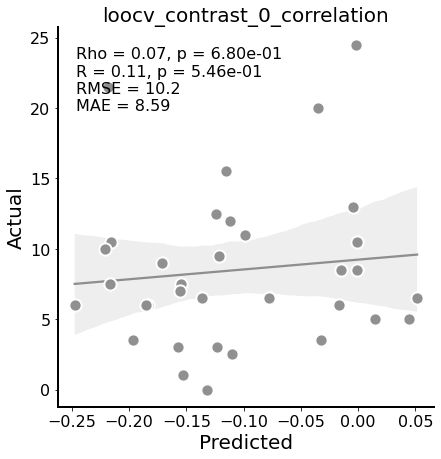

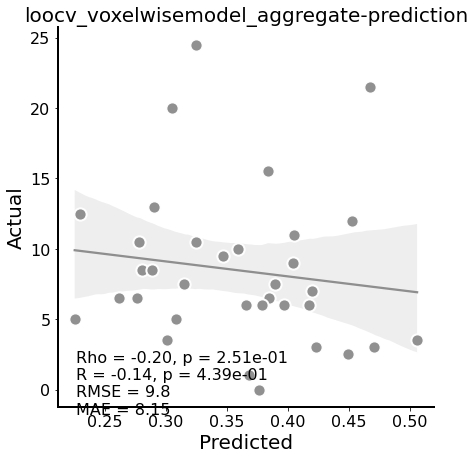

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]


2 predictions: 100%|██████████| 2/2 [00:00<00:00,  2.15it/s]


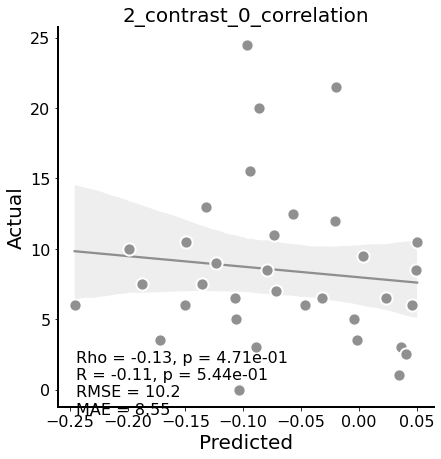

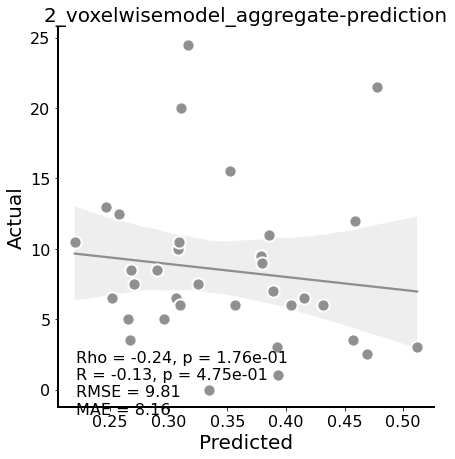

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]


5 predictions: 100%|██████████| 5/5 [00:01<00:00,  4.02it/s]


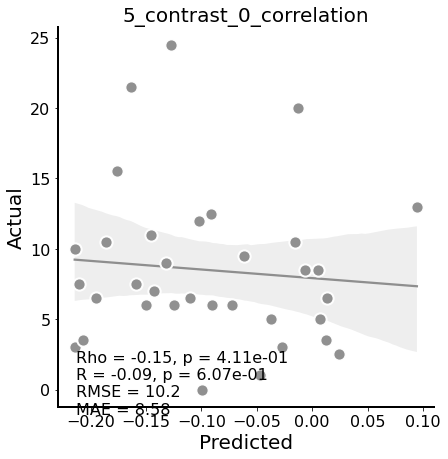

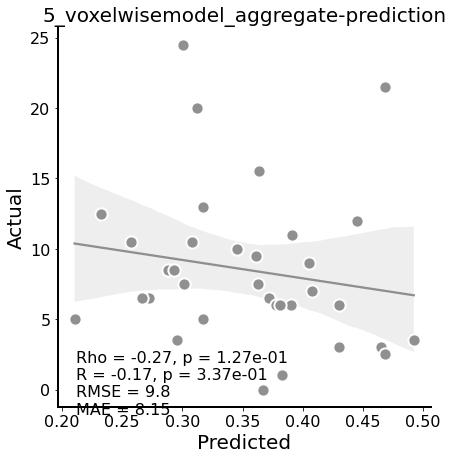

Attempting to import from pandas series. expecting PD series full of filenames. Will fail unless a series is provided using df["path_column"]


10 predictions: 100%|██████████| 10/10 [00:01<00:00,  5.92it/s]


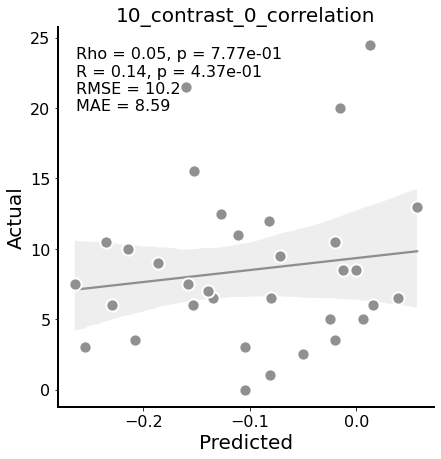

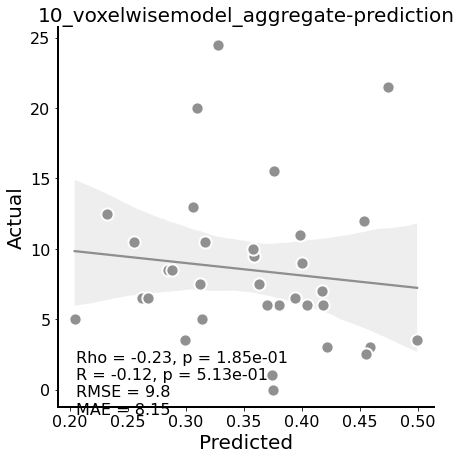

In [40]:
cv = regression.run_cross_validation(y_true=data_df["TotalBarsScore"], subject_files=data_df["onetouch_path"])

# 07 - Predict another dataset using the Fitted Voxelwise Regression

Import Data

In [26]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/master.csv'
sheet = None

In [27]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
test_df = cal_palm.read_and_display_data()
test_df

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/master.csv'

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [ ]:
test_df.columns

In [ ]:
drop_list = ['DX_BASELINE', 'fluid_atrophy_path_smoothed']

In [ ]:
test_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
test_df

**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [ ]:
test_df.columns

Set the parameters for dropping rows

In [ ]:
column = 'Cohort'  # The column you'd like to evaluate
condition = 'not'  # The condition to check ('equal', 'above', 'below', 'not')
value = 'Validation' # The value to drop if found

In [ ]:
test_df, _ = cal_palm.drop_rows_based_on_value(column, condition, value)
display(test_df)

Convert Categorical to Ordinal

Misc Changes

In [ ]:
import pandas as pd
one_hot = pd.get_dummies(test_df['DX_BASELINE'], prefix='DX_BASELINE', dtype=int)
test_df = test_df.join(one_hot)
test_df

Prepare Design and Outcome Matrices

In [ ]:
test_outcome_df, test_design_matrix = cal_palm.define_design_matrix(formula, test_df, add_intercept=False,
                                                          voxelwise_variable_list=voxelwise_variable_list, 
                                                          voxelwise_interaction_terms=voxelwise_interaction_terms)
test_design_matrix

Predict Another Dataset
- Import another dataset (currently cannot normalized to the other data's distribution, so make sure they are on the same scale)

In [ ]:
from calvin_utils.permutation_analysis_utils.voxelwise_regression_prep import RegressionPrep
preparer = RegressionPrep(design_matrix=test_design_matrix, 
                          contrast_matrix=contrast_matrix_df, 
                          outcome_df=test_outcome_df, 
                          out_dir=out_dir+'/test_predictions',
                          voxelwise_variables=voxelwise_variable_list, 
                          voxelwise_interactions=voxelwise_interaction_terms,
                          mask_path=mask_path, 
                          exchangeability_block=None, 
                          data_transform_method=None,
                          weights=None,
                          formula=formula)
test_dataset_dict, test_json_path = preparer.run()

- Run the fitted voxelwise model to generate prediction maps

In [ ]:
from calvin_utils.permutation_analysis_utils.voxelwise_regression import VoxelwiseRegression
regression = VoxelwiseRegression(test_json_path, mask_path=mask_path, out_dir=out_dir+'/test_predictions/regression_0', regression_type='linear', n_permutations=0)
results = regression.run_prediction(params_dir='/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/voxelwise/csf/regression_0')

Measure patient damage score with above Maps (from the above model's outputs or patient-wise predictions it has made) to measure 

In [ ]:
test_df.columns

In [ ]:
patient_nifti_col = ""  # e.g., "composite_atrophy_path_smoothed"
metric = ""             # fill with DamageScorer metric (e.g., "avg_in_subject")
threshold = ThresholdSpec(mode="above", value=2.0)  # set to None to skip thresholding
output_col = ""         # e.g., "pred0_avg_in_subject"
prediction_dir = ""     # e.g., f"{out_dir}/test_predictions/regression_0"
reference_nifti_path = ""  # set this OR prediction_dir (not both)

In [ ]:
from calvin_utils.permutation_analysis_utils import PredictionDamageScorer, ThresholdSpec
scorer = PredictionDamageScorer(df=df, mask_path=mask_path)

df = scorer.add_score_column(
    patient_nifti_col=patient_nifti_col,
    metric=metric,
    threshold=threshold,
    column_name=output_col,
    prediction_dir=prediction_dir,                              # Either set this
    reference_nifti_path=reference_nifti_path,                  # or this, but not both.
)

Use damage scores to perform regression or classification

In [ ]:
from calvin_utils.permutation_analysis_utils import BrainModelEvaluation

# ---- user-fill parameters ----
df = df  # dataframe containing prediction/observation columns
task = "regression"  # "regression" or "classification"

# Regression options
fitted_model = results  # statsmodels fitted model (set to None to use columns instead)
prediction_cols = ["pred_score"]  # used only if fitted_model is None
observation_cols = ["outcome"]    # used only if fitted_model is None
exog_df = design_matrix_df        # required if fitted_model is None

# Common options
out_dir = None  # set to a folder to save plots
show = True     # set False to suppress plotting

# ---- run ----
evaluator = BrainModelEvaluation(
    df=df,
    task=task,
    fitted_model=fitted_model,
    prediction_cols=prediction_cols,
    observation_cols=observation_cols,
    exog_df=exog_df,
    out_dir=out_dir,
    show=show,
)
evaluator.run()

That's all

-Calvin